In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(7)

city = "Івано-Франківськ"
base_temp = 7.8
amplitude = 12
base_consumption = 850
k = 22
noise_sd = 25

months = np.arange(1, 13)

temp = base_temp + amplitude * np.cos((months - 7) / 12 * 2 * np.pi)
temp = np.round(
    temp + np.random.normal(0, 0.5, size=12),
    1
)

consumption = (
    base_consumption
    - k * (temp - base_temp)
    + np.random.normal(0, noise_sd, size=12)
)

consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption
})

print(city_data)

    місяць  температура  споживання_МВтгод
0        1         -3.4             1109.0
1        2         -2.8             1077.0
2        3          1.8              976.0
3        4          8.0              809.0
4        5         13.4              741.0
5        6         18.2              624.0
6        7         19.8              593.0
7        8         17.3              603.0
8        9         14.3              748.0
9       10          8.1              847.0
10      11          1.5              979.0
11      12         -2.7             1132.0


In [3]:
print(city_data)
print()
print("Місто:", city)
print("Кількість спостережень:", len(city_data))

    місяць  температура  споживання_МВтгод
0        1         -3.4             1109.0
1        2         -2.8             1077.0
2        3          1.8              976.0
3        4          8.0              809.0
4        5         13.4              741.0
5        6         18.2              624.0
6        7         19.8              593.0
7        8         17.3              603.0
8        9         14.3              748.0
9       10          8.1              847.0
10      11          1.5              979.0
11      12         -2.7             1132.0

Місто: Івано-Франківськ
Кількість спостережень: 12


## Завдання 1. Класифікація сценарію

**1. Детермінована чи стохастична модель**

Модель споживання електроенергії як лінійної функції температури має вигляд `споживання = a + b · температура`. Сама лінійна частина є детермінованою, оскільки для однакового значення температури формула дає однакове прогнозоване значення. Проте фактичні дані містять випадкову складову, яка задається параметром `noise_sd` під час генерації споживання. Тому модель у цілому є **стохастичною**: вона складається з детермінованої середньої залежності та випадкового відхилення.

**2. Балансова, оптимізаційна, імітаційна чи жодна з цих**

Ця модель не є балансовою, оскільки в ній немає рівняння збереження або балансу ресурсів. Вона також не є оптимізаційною, тому що модель не шукає найкраще рішення за певним критерієм. Імітаційною її також не можна вважати, оскільки вона не відтворює покроково процес функціонування системи в часі. Отже, модель належить до **жодної з цих трьох категорій**. У цьому завданні вона використовується як описова та прогнозна статистична модель.

**3. Статична чи динамічна**

Модель є **статичною**, оскільки прогноз споживання для конкретного місяця залежить від температури цього самого місяця. Значення споживання попереднього місяця не використовується для розрахунку поточного прогнозу. Незважаючи на те, що спостереження впорядковані за 12 послідовними місяцями, модель не має механізму передачі стану системи від одного місяця до наступного.


In [4]:
b, a = np.polyfit(
    city_data["температура"],
    city_data["споживання_МВтгод"],
    1
)

print(f"споживання ≈ {a:.1f} + ({b:.1f}) · температура")

city_data["передбачення"] = (
    a + b * city_data["температура"]
)

print(city_data)

споживання ≈ 1028.5 + (-22.5) · температура
    місяць  температура  споживання_МВтгод  передбачення
0        1         -3.4             1109.0   1105.009509
1        2         -2.8             1077.0   1091.507882
2        3          1.8              976.0    987.995411
3        4          8.0              809.0    848.478602
4        5         13.4              741.0    726.963962
5        6         18.2              624.0    618.950948
6        7         19.8              593.0    582.946610
7        8         17.3              603.0    639.203388
8        9         14.3              748.0    706.711521
9       10          8.1              847.0    846.228331
10      11          1.5              979.0    994.746224
11      12         -2.7             1132.0   1089.257611


In [5]:
city_data["залишок"] = (
    city_data["споживання_МВтгод"]
    - city_data["передбачення"]
)

print(
    city_data[
        [
            "місяць",
            "температура",
            "споживання_МВтгод",
            "передбачення",
            "залишок"
        ]
    ]
)

    місяць  температура  споживання_МВтгод  передбачення    залишок
0        1         -3.4             1109.0   1105.009509   3.990491
1        2         -2.8             1077.0   1091.507882 -14.507882
2        3          1.8              976.0    987.995411 -11.995411
3        4          8.0              809.0    848.478602 -39.478602
4        5         13.4              741.0    726.963962  14.036038
5        6         18.2              624.0    618.950948   5.049052
6        7         19.8              593.0    582.946610  10.053390
7        8         17.3              603.0    639.203388 -36.203388
8        9         14.3              748.0    706.711521  41.288479
9       10          8.1              847.0    846.228331   0.771669
10      11          1.5              979.0    994.746224 -15.746224
11      12         -2.7             1132.0   1089.257611  42.742389


In [6]:
residuals = city_data["залишок"]

ss_res = (residuals ** 2).sum()

ss_tot = (
    (
        city_data["споживання_МВтгод"]
        - city_data["споживання_МВтгод"].mean()
    ) ** 2
).sum()

r_squared = 1 - ss_res / ss_tot

print(f"SS_res = {ss_res:.2f}")
print(f"SS_tot = {ss_tot:.2f}")
print(f"R² = {r_squared:.4f}")

SS_res = 7343.30
SS_tot = 432639.67
R² = 0.9830


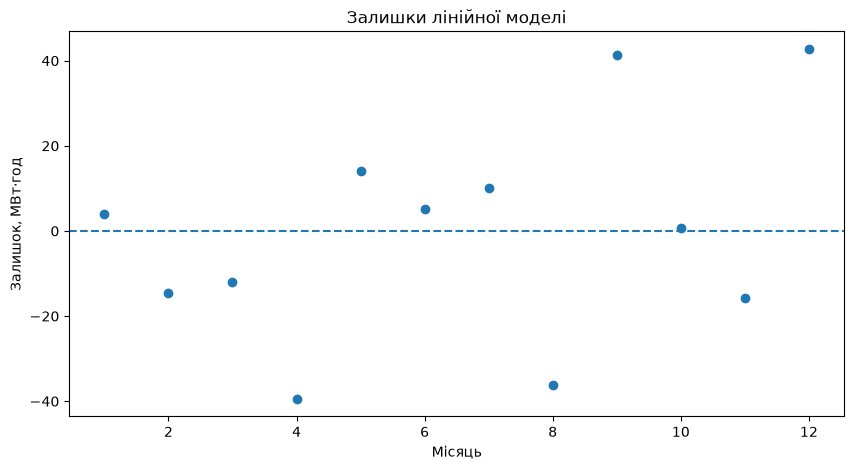

In [7]:
plt.figure(figsize=(10, 5))

plt.axhline(0, linestyle="--")
plt.scatter(
    city_data["місяць"],
    city_data["залишок"]
)

plt.xlabel("Місяць")
plt.ylabel("Залишок, МВт·год")
plt.title("Залишки лінійної моделі")

plt.show()

## Завдання 3. Порівняння передбачень зі спостереженнями й оцінка адекватності

Для кожного місяця було обчислено залишок як різницю між фактичним споживанням електроенергії та значенням, передбаченим лінійною моделлю:

`залишок = спостережене значення − передбачене значення`.

Коефіцієнт детермінації R² використано для кількісної оцінки того, яку частину варіації споживання пояснює температура.

Отримане значення R²: **[вставити значення з результату виконання коду]**.

На графіку залишків оцінюється їх розташування відносно нульової лінії. Якщо залишки розкидані без вираженої систематичної закономірності, це є ознакою того, що лінійна модель достатньо добре описує основну залежність між температурою та споживанням. Якщо ж спостерігається тренд або інша структура залишків, це означає, що лінійна форма моделі не враховує певну закономірність у даних.

Отже, адекватність моделі оцінюється не лише за величиною R², а одночасно за числовим показником та структурою залишків.


## Завдання 4. Верифікація і валідація для власної моделі

**Верифікація**

Верифікація коду підбору моделі означала б перевірку того, що реалізація правильно виконує задану формулу. Наприклад, після отримання коефіцієнтів `a` і `b` можна вручну розрахувати передбачення для одного місяця за формулою `a + b · температура` та порівняти його з відповідним значенням у стовпці `передбачення`. Якщо значення збігаються з результатом коду, це підтверджує правильність реалізації розрахунку.

**Валідація**

Валідація означала б перевірку того, наскільки побудована модель відповідає реальним спостереженням та чи може вона працювати на нових даних. Тих самих 12 спостережень, на яких були оцінені коефіцієнти `a` і `b`, недостатньо для чесної перевірки здатності моделі прогнозувати нові значення. Для повноцінної валідації бажано використати нові дані, наприклад спостереження за наступний рік, які не використовувалися під час підбору моделі. Це дозволить перевірити, наскільки модель узагальнюється на нові спостереження.


## Завдання 5. Пропозиція вдосконалення моделі

Для вдосконалення моделі доцільно розглянути окреме моделювання опалювального та теплого періодів року. Причина полягає в тому, що залежність споживання електроенергії від температури може мати різний характер за низьких і високих температур.

Проста одна пряма не враховує можливу зміну режиму споживання протягом року. Розділення даних на опалювальний та теплий періоди дозволило б побудувати окремі залежності та краще врахувати сезонну специфіку.

Водночас ускладнювати модель потрібно лише тоді, коли аналіз залишків покаже помітну систематичну закономірність. Якщо залишки не мають вираженої структури, додаткове ускладнення може бути недоцільним, оскільки потрібно зберігати компроміс між точністю моделі та її простотою.


## Контрольні питання

**1. За якими незалежними ознаками класифікується модель і чому ці ознаки не суперечать одна одній?**

Модель класифікується за різними незалежними ознаками. За характером випадковості вона є стохастичною, за типом використання — не балансовою, не оптимізаційною та не імітаційною, а за залежністю стану системи від попередніх моментів — статичною. Ці ознаки відповідають на різні питання про модель, тому не суперечать одна одній.

**2. Що показує отримане R² і чи доводить високе R², що модель правильна?**

R² показує частку варіації споживання електроенергії, яку пояснює температура в межах побудованої лінійної моделі. Високе R² саме по собі не доводить, що модель є повністю правильною або придатною для екстраполяції за межі спостережуваного діапазону температур. Необхідно також аналізувати залишки та перевіряти модель на нових даних.

**3. Чому структура залишків важливіша за одну лише сумарну величину відхилень?**

Структура залишків дозволяє визначити, чи містять помилки моделі систематичну закономірність. Якщо залишки випадково розкидані навколо нуля, модель не залишає очевидної неврахованої закономірності. Якщо ж залишки мають тренд або іншу структуру, це може свідчити про неправильну форму моделі або про фактор, який не був врахований.

**4. У чому різниця між верифікацією та валідацією для цієї моделі?**

Верифікація перевіряє правильність реалізації самого розрахунку моделі, наприклад правильність обчислення передбачення за формулою `a + b · температура`. Валідація перевіряє відповідність моделі реальним даним і її здатність робити прогнози для нових спостережень. Тобто верифікація відповідає на питання «чи правильно реалізована модель?», а валідація — «чи достатньо добре модель описує реальність і працює на нових даних?».


## Висновок

У практичній роботі було досліджено модель прогнозу місячного споживання електроенергії міста за середньомісячною температурою для варіанта 7 — Івано-Франківськ.

Модель було класифіковано як стохастичну, статичну та описову/прогнозну статистичну модель, яка не є балансовою, оптимізаційною або імітаційною.

На основі 12 місячних спостережень було підібрано просту лінійну модель залежності споживання від температури. Отриманий від'ємний коефіцієнт нахилу відповідає очікуваній закономірності: зі зростанням температури потреба в електроенергії на опалення зменшується.

Адекватність моделі оцінювалася за коефіцієнтом детермінації R² та за структурою залишків. Такий підхід дозволяє не обмежуватися одним числовим показником, а перевірити, чи залишаються в даних систематичні закономірності, які модель не враховує.

Також було розмежовано верифікацію та валідацію. Верифікація стосується правильності реалізації розрахунків, тоді як валідація потребує перевірки моделі на нових даних. Як можливе вдосконалення запропоновано врахування різних сезонних режимів споживання, якщо аналіз залишків покаже систематичні відхилення.

Отже, проста лінійна модель є зручною базовою моделлю для опису залежності споживання електроенергії від температури, а її подальше ускладнення доцільне лише за наявності підтвердженої структури в залишках.
